In [30]:
import sympy as sp

In [31]:
# Test: Analytic vs FFT Fresnel propagation of a 2D Gaussian (Goodman convention, ray-centered gauge)
# - Forward wave: exp(+i k z)
# - S2 = Q^{-1} with 1/q = 1/R + i*lambda/(pi*w^2)
# - Determinant factor carried in C (not S0)
#
# We compare analytic field to FFT Fresnel (transfer-function method) **including absolute phase**.

import numpy as np
import matplotlib.pyplot as plt

# ---------- Parameters (Goodman convention) ----------
wavelength = 137e-9   # 137 nm
k = 2*np.pi/wavelength
z = 0.12              # propagation distance (m)

# Astigmatic Gaussian at a waist (R = inf -> real(1/q)=0). Keep ray-centered gauge (center = 0, tilt = 0)
w0x = 0.35e-3         # 0.35 mm
w0y = 0.25e-3         # 0.25 mm
Rx = np.inf
Ry = np.inf

# Grid (choose generous sampling/extent to suppress aliasing)
N = 2048
L = 8e-3             # 8 mm window
dx = L / N
x = (np.arange(N) - N//2) * dx
X, Y = np.meshgrid(x, x, indexing="xy")

# ---------- Build initial Gaussian via action form ----------
# S2 = Q^{-1}; here at waist: 1/q = 1/R + i * lambda/(pi * w^2) with 1/R = 0
S2x = 1j * wavelength / (np.pi * w0x**2)     # scalar in x
S2y = 1j * wavelength / (np.pi * w0y**2)     # scalar in y
# For a separable astigmatic beam, S2 is diagonal
# Field: U0(x,y) = C0 * exp(i*k/2 * [x y] S2 [x;y]) = C0 * exp(i*k/2*(S2x*x^2 + S2y*y^2))
C0 = 1.0 + 0.0j      # carry absolute phase only via propagation; no extra initial phase
U0 = C0 * np.exp(1j * k * 0.5 * (S2x * X**2 + S2y * Y**2))

# ---------- Analytic propagation (free space A=I, B=zI, C=0, D=I) ----------
# S2' = S2 (I + z S2)^-1  (separable along axes)
S2x_p = S2x / (1 + z * S2x)
S2y_p = S2y / (1 + z * S2y)

# C' = C0 * exp(i k z) * det(I + z S2)^(-1/2)
#     For diagonal S2: det = (1 + z S2x)*(1 + z S2y)
det_fac = (1 + z * S2x) * (1 + z * S2y)
C_analytic = C0 * np.exp(1j * k * z) * det_fac**(-0.5)
U_analytic = C_analytic * np.exp(1j * k * 0.5 * (S2x_p * X**2 + S2y_p * Y**2))

# ---------- Numerical Fresnel via transfer function (FFT) ----------
# Fourier frequencies for numpy FFT (cycles per meter)
fx = np.fft.fftfreq(N, d=dx)   # unshifted
fy = np.fft.fftfreq(N, d=dx)
FX, FY = np.meshgrid(fx, fy, indexing="xy")

# Transfer function H(fx,fy) = exp(i k z) * exp(- i pi * lambda * z * (fx^2 + fy^2))
H = np.exp(1j * k * z) * np.exp(-1j * np.pi * wavelength * z * (FX**2 + FY**2))

# Apply FFT (no manual shifts if we keep the same convention for H and fields)
U0_fft = np.fft.fft2(U0)
Uz_fft = U0_fft * H
U_num = np.fft.ifft2(Uz_fft)

# ---------- Error metrics (absolute amplitude & absolute phase) ----------
# Compute complex ratio; if all is perfect including absolute phase, ratio ~ 1 everywhere.
ratio = U_num / U_analytic

amp_err = np.abs(U_num) - np.abs(U_analytic)
rel_amp_err = np.where(np.abs(U_analytic) > 0, amp_err / np.abs(U_analytic), 0.0)

# Phase error: angle(ratio) in radians; unwrap not needed for stats but we compute robust percentiles.
phase_err = np.angle(ratio)
phase_err_deg = np.degrees(phase_err)

def robust_stats(arr):
    return {
        "min": float(np.min(arr)),
        "p1": float(np.percentile(arr, 1)),
        "p50": float(np.percentile(arr, 50)),
        "p99": float(np.percentile(arr, 99)),
        "max": float(np.max(arr)),
        "rms": float(np.sqrt(np.mean(arr**2))),
        "mean": float(np.mean(arr))
    }

metrics = {
    "abs_phase_error_deg": robust_stats(phase_err_deg),
    "rel_amp_error": robust_stats(rel_amp_err),
    "max_abs_amp_diff": float(np.max(np.abs(amp_err))),
    "L2_rel_error": float(np.linalg.norm(U_num - U_analytic) / np.linalg.norm(U_analytic))
}

metrics


{'abs_phase_error_deg': {'min': -180.0,
  'p1': -176.33785484115094,
  'p50': -1.0584945404743836e-11,
  'p99': 175.77103445870296,
  'max': 180.0,
  'rms': 94.87960712648969,
  'mean': -3.0098888815573672},
 'rel_amp_error': {'min': -1.0,
  'p1': -0.013217785932116394,
  'p50': 1.605845855826792e+33,
  'p99': 5.42209586541749e+128,
  'max': 3.947211845613744e+150,
  'rms': 4.250432910844554e+147,
  'mean': 1.7183065748168477e+145},
 'max_abs_amp_diff': 4.440892098500626e-16,
 'L2_rel_error': 4.353230639969004e-16}

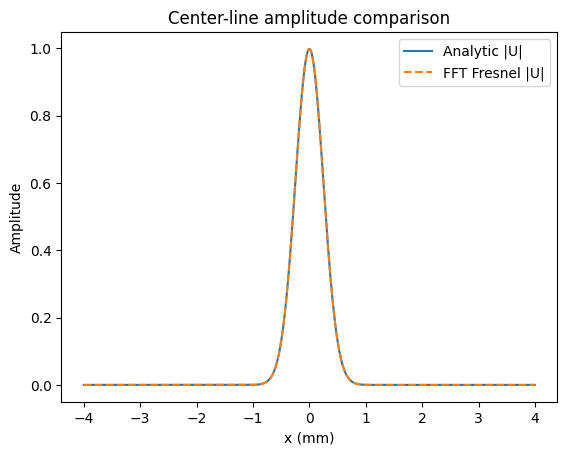

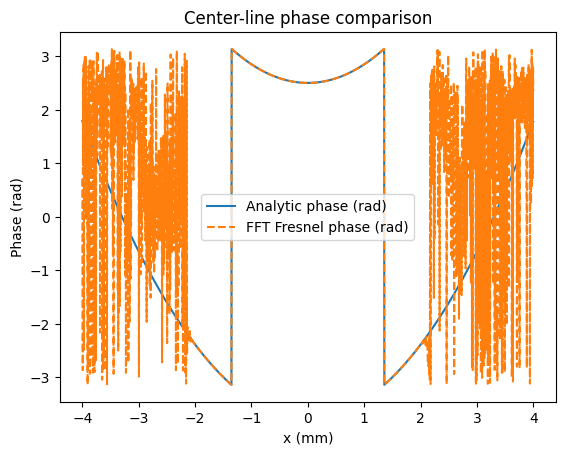

In [32]:
# Center-line comparison of amplitudes
center = U_analytic.shape[0] // 2
x_axis = X[center, :]

plt.figure()
plt.plot(x_axis*1e3, np.abs(U_analytic[center, :]), label="Analytic |U|")
plt.plot(x_axis*1e3, np.abs(U_num[center, :]), linestyle="--", label="FFT Fresnel |U|")
plt.xlabel("x (mm)")
plt.ylabel("Amplitude")
plt.title("Center-line amplitude comparison")
plt.legend()
plt.show()

plt.figure()
plt.plot(x_axis*1e3, np.angle(U_analytic[center, :]), label="Analytic phase (rad)")
plt.plot(x_axis*1e3, np.angle(U_num[center, :]), linestyle="--", label="FFT Fresnel phase (rad)")
plt.xlabel("x (mm)")
plt.ylabel("Phase (rad)")
plt.title("Center-line phase comparison")
plt.legend()
plt.show()